# Week 9 Jupyter Notebook — Gradient Boosting

## Objective

This notebook applies Week 9 Gradient Boosting methods to my airline delay capstone project. The target variable is `DEP_DEL15`, which shows whether a flight was delayed by at least 15 minutes.

For this week, I tested gradient boosting, learning rate, number of estimators, tree depth, and regularization-related settings. I also compared training and validation performance to check for overfitting.

Project: Predicting U.S. airline delay risk using 2019 airline data.


In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` file. The BTS `Flight_Delay.csv` file is included as supporting context for 2019 delay causes.

Gradient boosting can take longer than simpler models, so this notebook uses a moderate sample size.


In [4]:
SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)

# Optional supporting dataset.
try:
    delay = pd.read_csv("data/Flight_delay.csv")
    print("BTS delay file shape:", delay.shape)
except FileNotFoundError:
    print("BTS delay file not found. Continuing with Kaggle train.csv only.")

print("Train shape:", train.shape)
train.head()


BTS delay file shape: (484551, 29)
Train shape: (50000, 30)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`.

- `0` means the flight was not delayed by 15 or more minutes.
- `1` means the flight was delayed by 15 or more minutes.

Because the delayed class is smaller than the non-delayed class, I use more than accuracy to evaluate the models.


Target counts:
DEP_DEL15
0    40520
1     9480
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.04
1    18.96
Name: proportion, dtype: float64


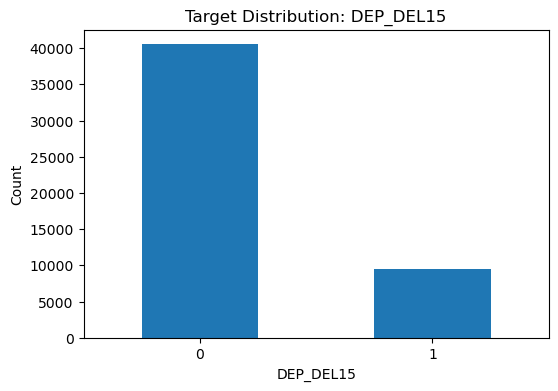

In [5]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

plt.figure(figsize=(6, 4))
train[target].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("DEP_DEL15")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 3. Select features

I used the same main numeric predictors from the earlier notebooks. These include weather, airport activity, carrier history, time, and operational sequence variables.

Gradient boosting can capture nonlinear relationships and interactions between these variables.


In [6]:
target = "DEP_DEL15"

numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in numeric_candidates if col in train.columns]

print("Target:", target)
print("Number of features used:", len(features))
print(features)


Target: DEP_DEL15
Number of features used: 25
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Prepare train and validation data

I used a stratified train/validation split so the class balance stays similar in both sets.


In [7]:
# Keep only the target and selected numeric features.
model_data = train[features + [target]].copy()

# Remove missing values so the models can run cleanly.
model_data = model_data.dropna()

X = model_data[features]
y = model_data[target].astype(int)

print("Modeling data shape:", model_data.shape)
print("Delay rate:", round(y.mean(), 4))

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])


Modeling data shape: (50000, 26)
Delay rate: 0.1896
Training rows: 37500
Validation rows: 12500


## 5. Evaluation function and baseline

I used accuracy, precision, recall, F1-score, and ROC-AUC. Since delays are the smaller class, F1-score, recall, and ROC-AUC are more useful than accuracy alone.


In [8]:
def evaluate_classifier(model, X_valid, y_valid, label):
    preds = model.predict(X_valid)

    # Some models have predict_proba, which lets us calculate ROC-AUC.
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, probs)
    else:
        probs = None
        auc = np.nan

    return {
        "Model": label,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds, zero_division=0),
        "Recall": recall_score(y_valid, preds, zero_division=0),
        "F1": f1_score(y_valid, preds, zero_division=0),
        "ROC_AUC": auc
    }

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_results = evaluate_classifier(baseline, X_valid, y_valid, "Baseline: most frequent class")
pd.DataFrame([baseline_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline: most frequent class,0.8104,0.0,0.0,0.0,0.5


## 6. Basic Gradient Boosting model

Gradient boosting builds trees sequentially. Each new tree tries to correct errors from the previous trees. This makes the model more flexible than a single decision tree, but it also means the model needs tuning to avoid overfitting.


In [9]:
gb_default = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_default.fit(X_train, y_train)

default_results = evaluate_classifier(gb_default, X_valid, y_valid, "Default Gradient Boosting")
pd.DataFrame([baseline_results, default_results]).round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline: most frequent class,0.8104,0.0000,0.0000,0.0000,0.5000
1,Default Gradient Boosting,0.8154,0.6413,0.0603,0.1103,0.6915


## 7. Tune learning rate, estimators, tree depth, and regularization

The main hyperparameters I tested were:

- `learning_rate`: how strongly each new tree changes the model
- `n_estimators`: how many boosting stages/trees are added
- `max_depth`: how complex each tree can be
- `subsample`: using less than all training rows can add regularization
- `min_samples_leaf`: requiring more samples in a leaf can reduce overfitting

A lower learning rate can help reduce overfitting because each tree has less influence, but it often needs more estimators.


In [10]:
param_grid = [
    {"learning_rate": 0.03, "n_estimators": 100, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.05, "n_estimators": 100, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.10, "n_estimators": 100, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.10, "n_estimators": 100, "max_depth": 3, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.10, "n_estimators": 150, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.20, "n_estimators": 100, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 20},
    {"learning_rate": 0.10, "n_estimators": 100, "max_depth": 2, "subsample": 1.0, "min_samples_leaf": 1},
]

tuning_results = []

for params in param_grid:
    model = GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **params
    )

    model.fit(X_train, y_train)

    train_probs = model.predict_proba(X_train)[:, 1]
    valid_probs = model.predict_proba(X_valid)[:, 1]

    row = evaluate_classifier(
        model,
        X_valid,
        y_valid,
        f"GB lr={params['learning_rate']}, est={params['n_estimators']}, depth={params['max_depth']}"
    )

    row.update(params)
    row["Train_ROC_AUC"] = roc_auc_score(y_train, train_probs)
    row["Valid_ROC_AUC"] = roc_auc_score(y_valid, valid_probs)
    row["AUC_Gap"] = row["Train_ROC_AUC"] - row["Valid_ROC_AUC"]
    tuning_results.append(row)

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("Valid_ROC_AUC", ascending=False).round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,learning_rate,n_estimators,max_depth,subsample,min_samples_leaf,Train_ROC_AUC,Valid_ROC_AUC,AUC_Gap
3,"GB lr=0.1, est=100, depth=3",0.8146,0.6137,0.0603,0.1099,0.6917,0.10,100,3,0.8,20,0.7114,0.6917,0.0197
5,"GB lr=0.2, est=100, depth=2",0.8146,0.6221,0.0570,0.1044,0.6914,0.20,100,2,0.8,20,0.7042,0.6914,0.0127
4,"GB lr=0.1, est=150, depth=2",0.8146,0.6402,0.0511,0.0946,0.6904,0.10,150,2,0.8,20,0.6999,0.6904,0.0096
2,"GB lr=0.1, est=100, depth=2",0.8137,0.6323,0.0414,0.0776,0.6869,0.10,100,2,0.8,20,0.6933,0.6869,0.0064
6,"GB lr=0.1, est=100, depth=2",0.8137,0.6414,0.0392,0.0740,0.6853,0.10,100,2,1.0,1,0.6931,0.6853,0.0078
1,"GB lr=0.05, est=100, depth=2",0.8119,0.6092,0.0224,0.0431,0.6773,0.05,100,2,0.8,20,0.6824,0.6773,0.0052
0,"GB lr=0.03, est=100, depth=2",0.8106,0.5429,0.0080,0.0158,0.6714,0.03,100,2,0.8,20,0.6753,0.6714,0.0039


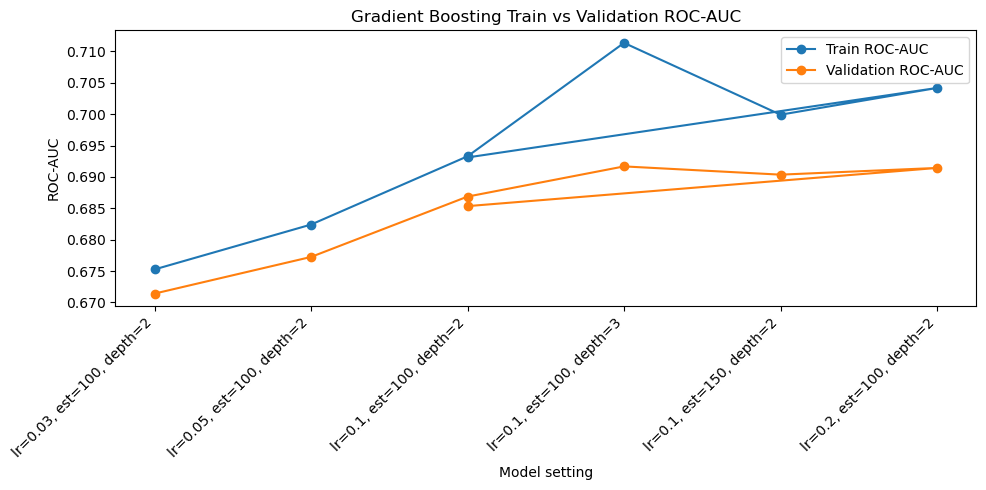

In [11]:
plot_df = tuning_df.copy()
plot_df["Model_Setting"] = (
    "lr=" + plot_df["learning_rate"].astype(str)
    + ", est=" + plot_df["n_estimators"].astype(str)
    + ", depth=" + plot_df["max_depth"].astype(str)
)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Model_Setting"], plot_df["Train_ROC_AUC"], marker="o", label="Train ROC-AUC")
plt.plot(plot_df["Model_Setting"], plot_df["Valid_ROC_AUC"], marker="o", label="Validation ROC-AUC")
plt.title("Gradient Boosting Train vs Validation ROC-AUC")
plt.xlabel("Model setting")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Best Gradient Boosting model

I selected the best gradient boosting model by validation ROC-AUC. I also checked the train-validation gap because a large gap would suggest overfitting.


In [12]:
best_row = tuning_df.sort_values("Valid_ROC_AUC", ascending=False).iloc[0]

best_params = {
    "learning_rate": best_row["learning_rate"],
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": int(best_row["max_depth"]),
    "subsample": best_row["subsample"],
    "min_samples_leaf": int(best_row["min_samples_leaf"])
}

print("Best parameters:")
print(best_params)

best_gb = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    **best_params
)

best_gb.fit(X_train, y_train)

best_results = evaluate_classifier(best_gb, X_valid, y_valid, "Best tuned Gradient Boosting")
pd.DataFrame([baseline_results, default_results, best_results]).round(4)


Best parameters:
{'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 3, 'subsample': 0.8, 'min_samples_leaf': 20}


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline: most frequent class,0.8104,0.0000,0.0000,0.0000,0.5000
1,Default Gradient Boosting,0.8154,0.6413,0.0603,0.1103,0.6915
2,Best tuned Gradient Boosting,0.8146,0.6137,0.0603,0.1099,0.6917


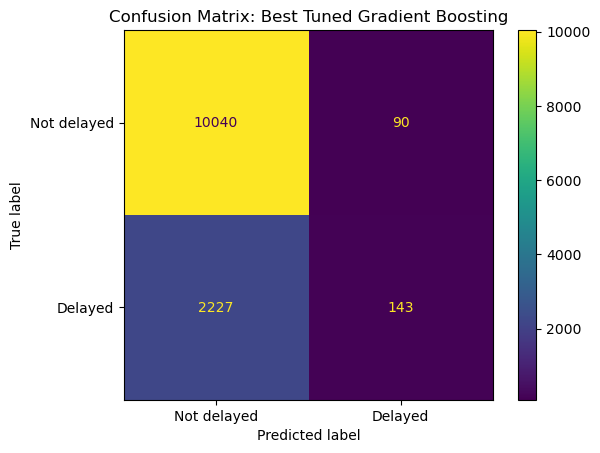

Confusion matrix:
[[10040    90]
 [ 2227   143]]


In [13]:
best_preds = best_gb.predict(X_valid)

cm = confusion_matrix(y_valid, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not delayed", "Delayed"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: Best Tuned Gradient Boosting")
plt.show()

print("Confusion matrix:")
print(cm)


## 9. Feature importance

Gradient boosting can show which features contributed most to the model. This is useful for my capstone because I want to know what types of variables are most connected to delay risk.


In [14]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_gb.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
24,DEP_BLOCK_HIST,0.364645
16,PRCP,0.151704
21,CARRIER_HISTORICAL,0.059594
22,DEP_AIRPORT_HIST,0.054116
3,SEGMENT_NUMBER,0.049509
20,AWND,0.038488
19,TMAX,0.034143
6,AIRPORT_FLIGHTS_MONTH,0.031938
7,AIRLINE_FLIGHTS_MONTH,0.024874
8,AIRLINE_AIRPORT_FLIGHTS_MONTH,0.023285


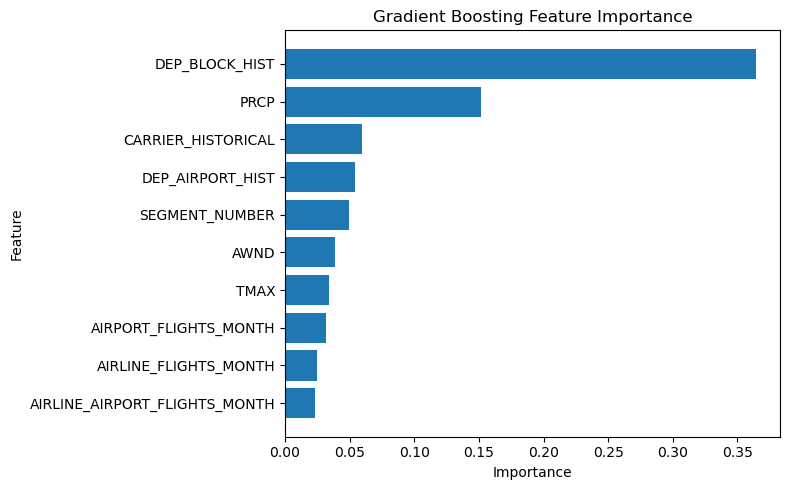

In [15]:
top_importance = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Week 9 conclusion

Gradient boosting was a strong fit for this project because airline delay risk is not a simple linear problem. The model builds many small trees in sequence, so it can learn nonlinear patterns and interactions between operational, weather, carrier, and historical delay variables.

To reduce overfitting, I tuned the learning rate, number of estimators, tree depth, subsampling, and minimum samples per leaf. The train-versus-validation ROC-AUC comparison helped show whether the model was generalizing or just fitting the training data too closely.

The most useful features were expected to be historical and operational variables, similar to the random forest results from Week 6. This is important because it supports the idea that flight delays are a system-level issue. Delay risk is more connected to airport conditions, carrier history, weather, and previous delay patterns than one simple variable.